In [24]:
df = '/content/company_esg_financial_dataset.csv'

In [25]:
import pandas as pd
file_path = '/content/company_esg_financial_dataset.csv'
df = pd.read_csv(file_path)
display(df.head())

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [26]:
# Duplicated
df.duplicated().sum()

np.int64(0)

In [27]:
# Missing values
df.isnull().sum()

,0
CompanyID,0
CompanyName,0
Industry,0
Region,0
Year,0
Revenue,0
ProfitMargin,0
MarketCap,0
GrowthRate,1000
ESG_Overall,0


In [28]:
df['Carbon_Intensity'] = df['CarbonEmissions'] / df['Revenue']
df['Water_Intensity'] = df['WaterUsage'] / df['Revenue']
df['Energy_Intensity'] = df['EnergyConsumption'] / df['Revenue']

In [29]:
df.to_csv('company_esg_financial_dataset_transformative_metrics.csv', index=False)

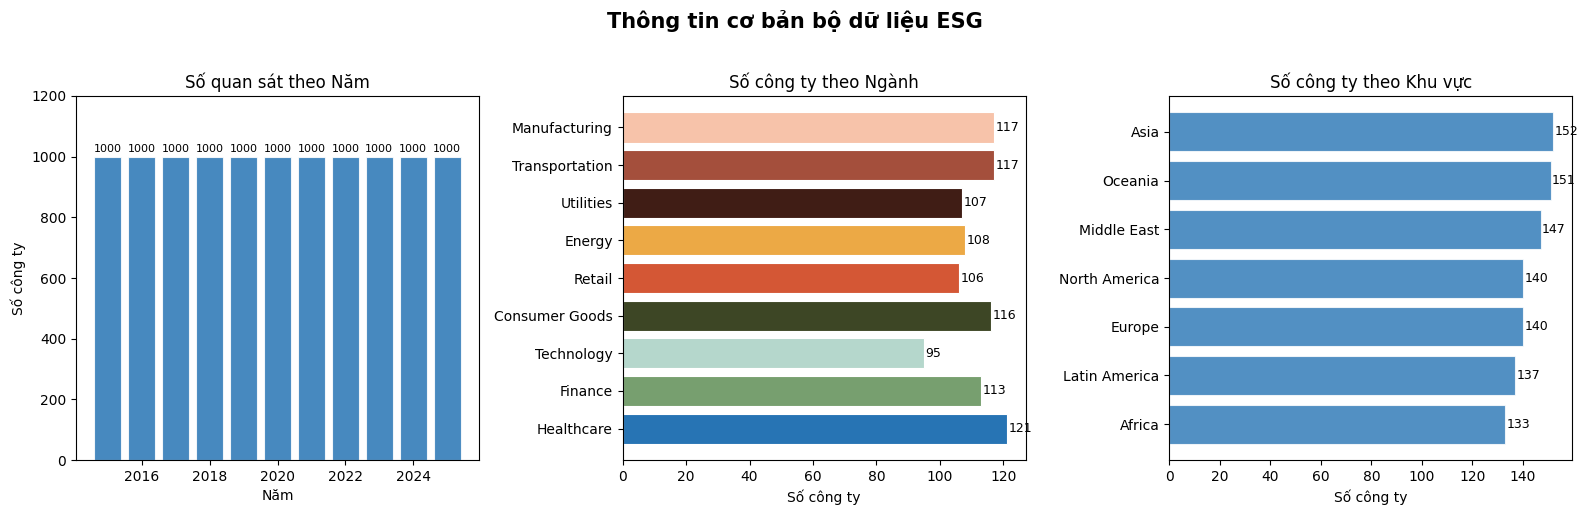

Saved: 01_basic_info.png


In [30]:
import matplotlib.pyplot as plt

INDUSTRY_COLORS = {
    'Healthcare': '#2774B4',
    'Finance': '#779F6F',
    'Technology': '#B5D7CC',
    'Consumer Goods': '#3D4625',
    'Retail': '#D45735',
    'Energy': '#ECA945',
    'Utilities': '#401D15',
    'Transportation': '#A44F3C',
    'Manufacturing': '#F7C3AA'
}

DESIRED_ORDER = ['Healthcare', 'Finance', 'Technology', 'Consumer Goods',
                 'Retail', 'Energy', 'Utilities', 'Transportation', 'Manufacturing']

yearly = df.groupby('Year').size()

ind_count = df.groupby('Industry')['CompanyID'].nunique()
ind_count = ind_count.reindex([ind for ind in DESIRED_ORDER if ind in ind_count.index])
colors_ind = [INDUSTRY_COLORS[ind] for ind in ind_count.index]

reg_count = df.groupby('Region')['CompanyID'].nunique().sort_values()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Thông tin cơ bản bộ dữ liệu ESG', fontsize=15, fontweight='bold', y=1.02)

bars_yr = axes[0].bar(yearly.index, yearly.values, color='#2774B4', alpha=0.85,
                      edgecolor='white', linewidth=0.8)
axes[0].set_title('Số quan sát theo Năm')
axes[0].set_xlabel('Năm')
axes[0].set_ylabel('Số công ty')
axes[0].set_ylim(0, 1200)
for bar, v in zip(bars_yr, yearly.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 10,
                 str(v), ha='center', va='bottom', fontsize=8)

bars_ind = axes[1].barh(ind_count.index, ind_count.values,
                        color=colors_ind, edgecolor='white', linewidth=0.8)
axes[1].set_title('Số công ty theo Ngành')
axes[1].set_xlabel('Số công ty')
for bar, v in zip(bars_ind, ind_count.values):
    axes[1].text(v + 0.5, bar.get_y() + bar.get_height()/2,
                 str(v), va='center', fontsize=9)

bars_reg = axes[2].barh(reg_count.index, reg_count.values,
                        color='#2774B4', alpha=0.80, edgecolor='white', linewidth=0.8)
axes[2].set_title('Số công ty theo Khu vực')
axes[2].set_xlabel('Số công ty')
for bar, v in zip(bars_reg, reg_count.values):
    axes[2].text(v + 0.5, bar.get_y() + bar.get_height()/2,
                 str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('01_basic_info.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_basic_info.png")

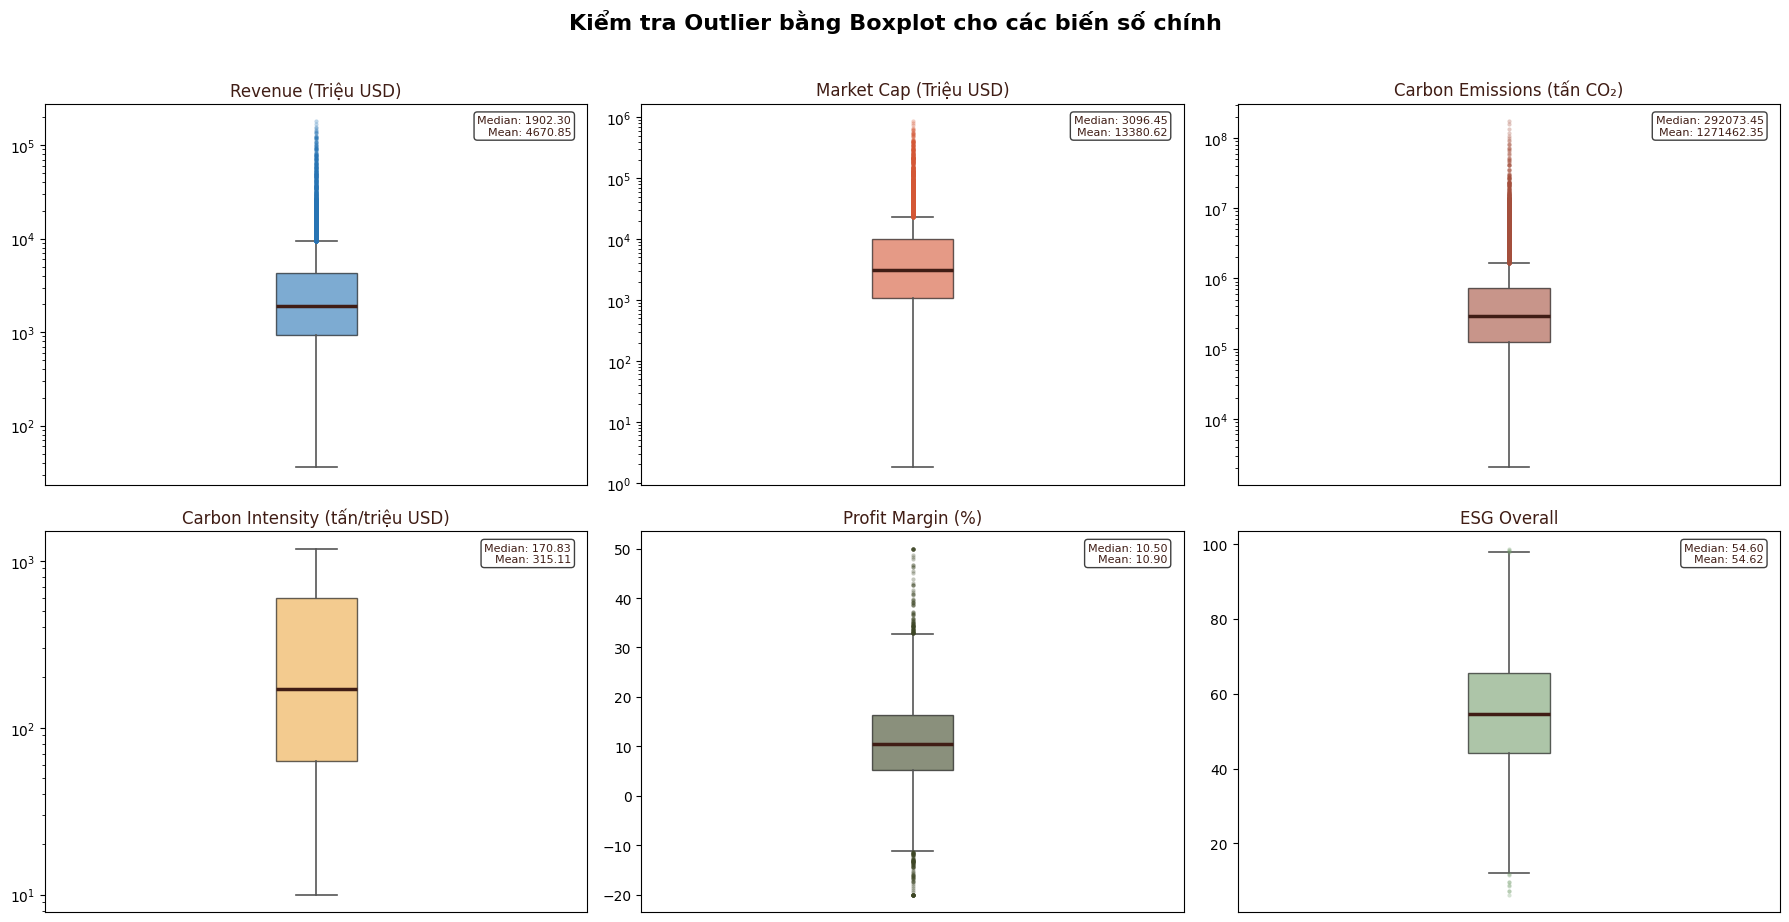

Saved: 03_outlier_boxplot.png


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


COLOR_MAP = {
    'Revenue': '#2774B4',
    'MarketCap': '#D45735',
    'CarbonEmissions': '#A44F3C',
    'Carbon_Intensity': '#ECA945',
    'ProfitMargin': '#3D4625',
    'ESG_Overall': '#779F6F',
}

variables = ['Revenue', 'MarketCap', 'CarbonEmissions', 'Carbon_Intensity', 'ProfitMargin', 'ESG_Overall']
labels = {
    'Revenue': 'Revenue (Triệu USD)',
    'MarketCap': 'Market Cap (Triệu USD)',
    'CarbonEmissions': 'Carbon Emissions (tấn CO₂)',
    'Carbon_Intensity': 'Carbon Intensity (tấn/triệu USD)',
    'ProfitMargin': 'Profit Margin (%)',
    'ESG_Overall': 'ESG Overall'
}

use_log = ['Revenue', 'MarketCap', 'CarbonEmissions', 'Carbon_Intensity']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Kiểm tra Outlier bằng Boxplot cho các biến số chính',
             fontsize=16, fontweight='bold', y=1.02)

for idx, var in enumerate(variables):
    ax = axes[idx // 3, idx % 3]
    data = df[var].dropna()
    color = COLOR_MAP[var]

    bp = ax.boxplot(
        data, vert=True, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='#401D15', linewidth=2.5),
        whiskerprops=dict(color='#555555', linewidth=1.2),
        capprops=dict(color='#555555', linewidth=1.2),
        flierprops=dict(marker='o', markerfacecolor=color,
                        markeredgecolor='none', markersize=3, alpha=0.3)
    )

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_out = int(((data < lower_bound) | (data > upper_bound)).sum())
    pct_out = n_out / len(data) * 100

    if var in use_log:
        ax.set_yscale('log')

    ax.set_title(labels[var], fontsize=12, color='#401D15')
    ax.set_xticks([])

    # Thống kê cơ bản
    ax.text(0.97, 0.97,
            f'Median: {data.median():.2f}\nMean: {data.mean():.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='#401D15',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75))

plt.tight_layout()
plt.savefig('03_outlier_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_outlier_boxplot.png")

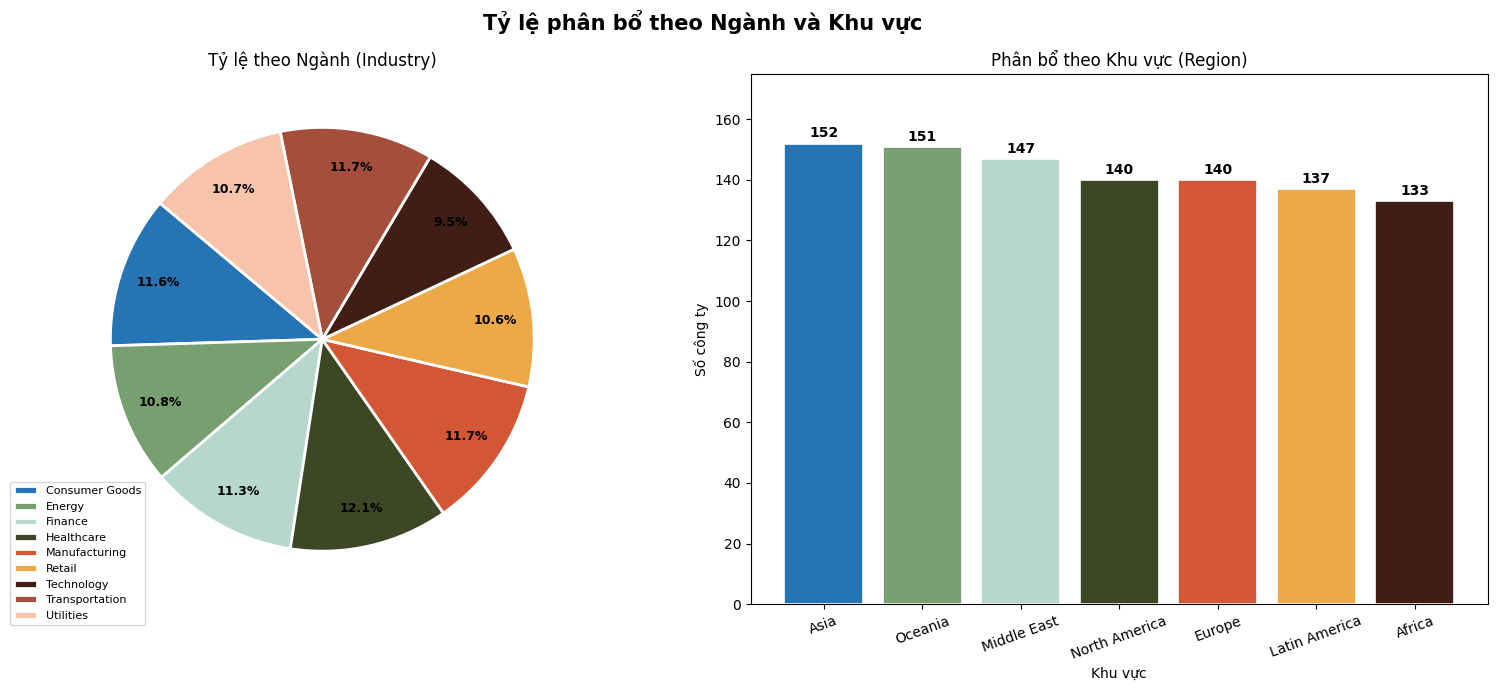

Saved: 04_categorical.png


In [32]:
PALETTE = list(INDUSTRY_COLORS.values())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Tỷ lệ phân bổ theo Ngành và Khu vực', fontsize=15, fontweight='bold')

ind_pct = df.groupby('Industry')['CompanyID'].nunique()
wedges, texts, autotexts = axes[0].pie(
    ind_pct.values,
    labels=None,
    autopct='%1.1f%%',
    colors=PALETTE[:len(ind_pct)],
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
axes[0].set_title('Tỷ lệ theo Ngành (Industry)')
axes[0].legend(
    ind_pct.index,
    loc='lower left',
    fontsize=8,
    framealpha=0.8,
    bbox_to_anchor=(-0.1, -0.05)
)

reg_count = df.groupby('Region')['CompanyID'].nunique().sort_values(ascending=False)
bars = axes[1].bar(
    reg_count.index, reg_count.values,
    color=PALETTE[:len(reg_count)],
    edgecolor='white', linewidth=1.2
)
axes[1].set_title('Phân bổ theo Khu vực (Region)')
axes[1].set_xlabel('Khu vực')
axes[1].set_ylabel('Số công ty')
axes[1].tick_params(axis='x', rotation=20)
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[1].set_ylim(0, max(reg_count.values) * 1.15)

plt.tight_layout()
plt.savefig('04_categorical.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_categorical.png")

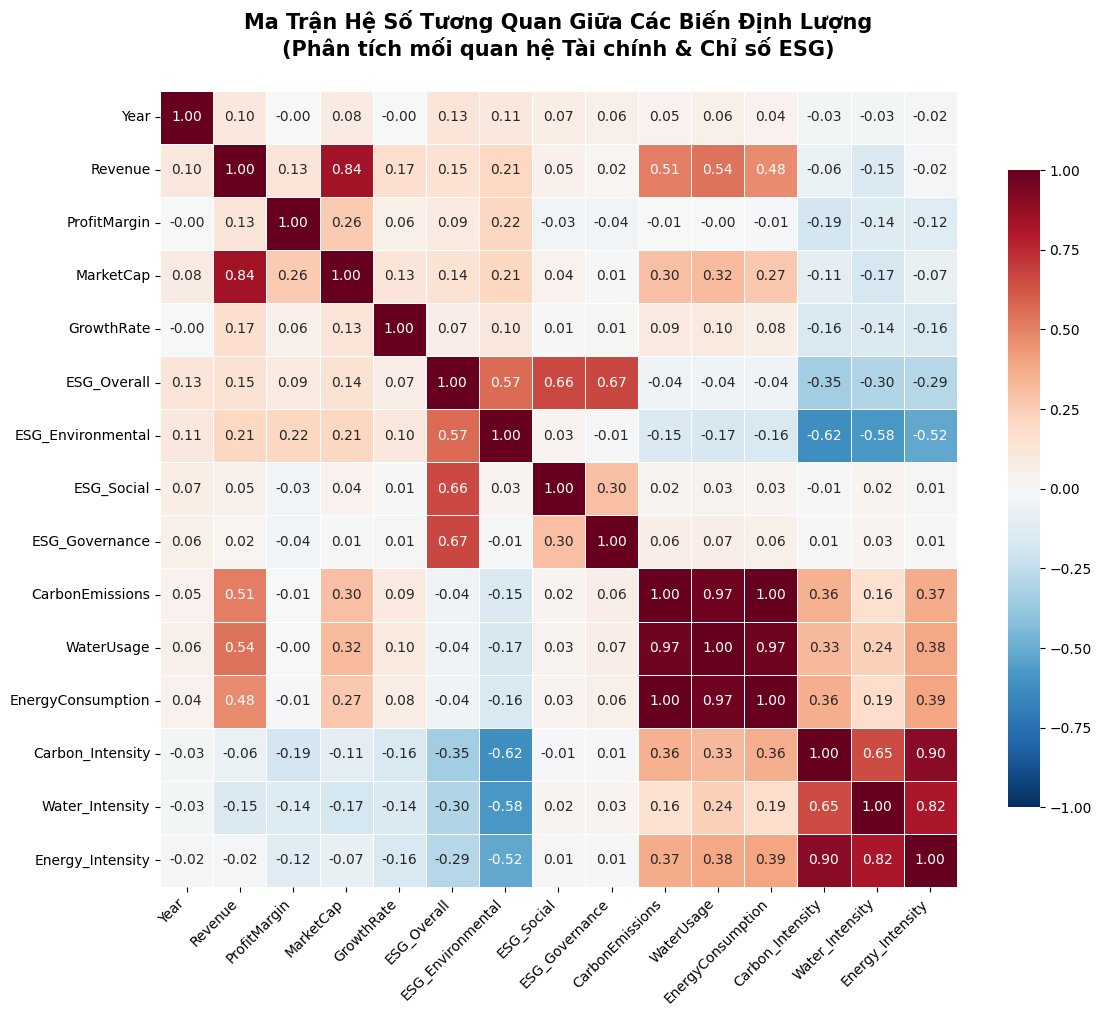

In [33]:
import seaborn as sns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

if 'CompanyID' in numeric_cols:
    numeric_cols = numeric_cols.drop('CompanyID')

if len(numeric_cols) > 0:
    plt.figure(figsize=(12, 10))

    corr_matrix = df[numeric_cols].corr()

    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='RdBu_r',
        fmt=".2f",
        linewidths=0.5,
        vmin=-1,
        vmax=1,
        square=True,
        cbar_kws={"shrink": .8}
    )

    plt.title('Ma Trận Hệ Số Tương Quan Giữa Các Biến Định Lượng\n(Phân tích mối quan hệ Tài chính & Chỉ số ESG)', fontsize=15, pad=25, fontweight='bold')

    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("Cảnh báo: Không tìm thấy cột dữ liệu định lượng nào phù hợp trong dataset.")

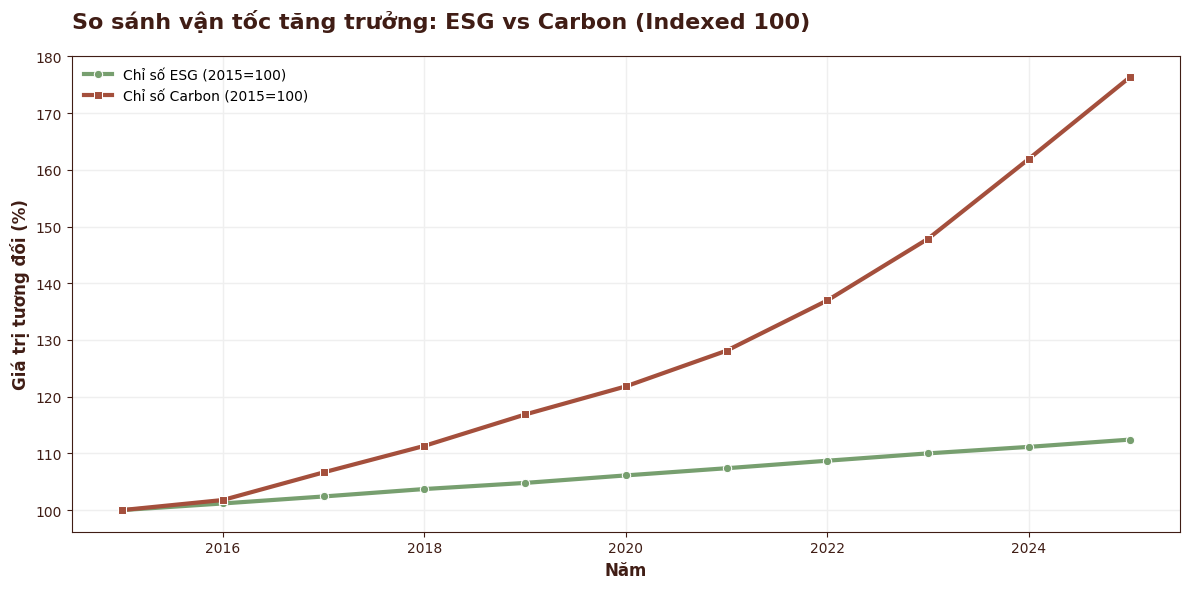

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

plt.rcParams['font.family'] = 'sans-serif'

COLOR_TEXT = '#401D15'
COLOR_GRID = '#EFEFEF'
COLOR_ESG = '#779F6F'
COLOR_CARBON = '#A44F3C'

year_data_idx = df.groupby('Year').agg({'ESG_Overall': 'mean', 'CarbonEmissions': 'mean'}).reset_index()
for col in ['ESG_Overall', 'CarbonEmissions']:
    initial_val = year_data_idx.loc[0, col]
    year_data_idx[f'{col}_Index'] = (year_data_idx[col] / initial_val) * 100

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

sns.lineplot(x='Year', y='ESG_Overall_Index', data=year_data_idx, marker='o',
             color=COLOR_ESG, label='Chỉ số ESG (2015=100)', linewidth=3, ax=ax)
sns.lineplot(x='Year', y='CarbonEmissions_Index', data=year_data_idx, marker='s',
             color=COLOR_CARBON, label='Chỉ số Carbon (2015=100)', linewidth=3, ax=ax)

ax.set_title('So sánh vận tốc tăng trưởng: ESG vs Carbon (Indexed 100)',
             fontsize=16, fontweight='bold', color=COLOR_TEXT, pad=20, loc='left')
ax.set_xlabel('Năm', fontsize=12, fontweight='bold', color=COLOR_TEXT)
ax.set_ylabel('Giá trị tương đối (%)', fontsize=12, fontweight='bold', color=COLOR_TEXT)

ax.grid(True, color=COLOR_GRID, linestyle='-', linewidth=1)
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_edgecolor(COLOR_TEXT)

ax.tick_params(colors=COLOR_TEXT)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

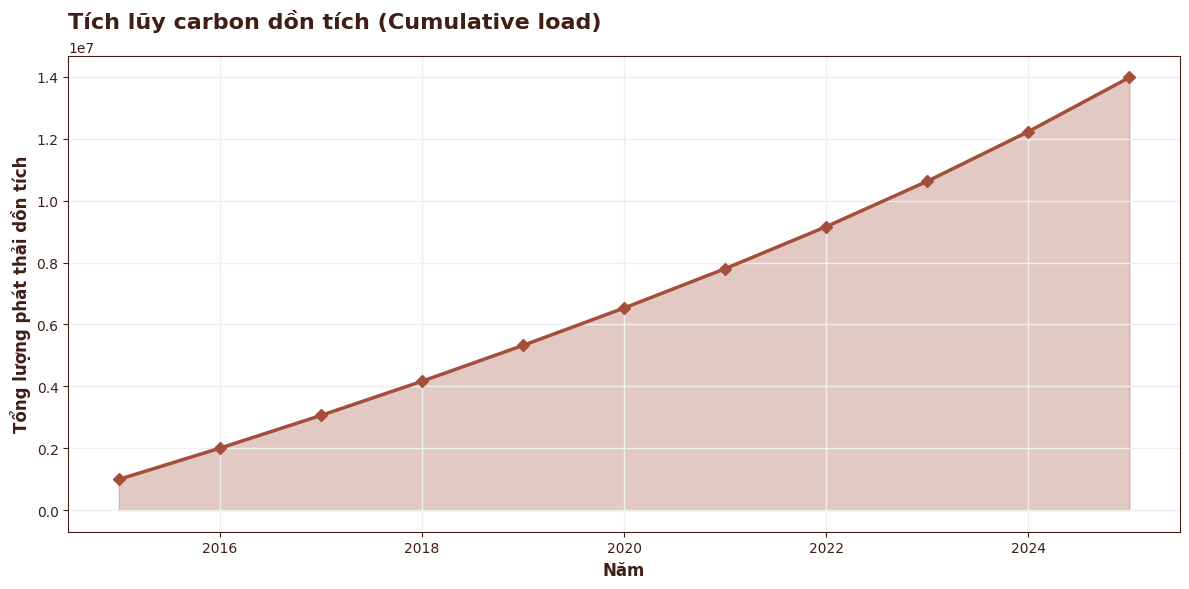

In [64]:
import matplotlib.pyplot as plt
import numpy as np

COLOR_TEXT = '#401D15'
COLOR_GRID = '#EFEFEF'
COLOR_FILL = '#A44F3C'

year_data_idx['Cumulative_Carbon'] = year_data_idx['CarbonEmissions'].cumsum()

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

ax.fill_between(year_data_idx['Year'], year_data_idx['Cumulative_Carbon'],
                color=COLOR_FILL, alpha=0.3, label='Tải trọng Carbon dồn tích')
ax.plot(year_data_idx['Year'], year_data_idx['Cumulative_Carbon'],
        color=COLOR_FILL, marker='D', linewidth=2.5)

ax.set_title('Tích lũy carbon dồn tích (Cumulative load)',
             fontsize=16, fontweight='bold', color=COLOR_TEXT, pad=20, loc='left')
ax.set_xlabel('Năm', fontsize=12, fontweight='bold', color=COLOR_TEXT)
ax.set_ylabel('Tổng lượng phát thải dồn tích', fontsize=12, fontweight='bold', color=COLOR_TEXT)

ax.grid(True, color=COLOR_GRID, linestyle='-', linewidth=1)
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_edgecolor(COLOR_TEXT)

ax.tick_params(colors=COLOR_TEXT)
plt.tight_layout()
plt.show()

In [34]:
import plotly.express as px

heatmap_cols = ['ESG_Overall', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']

corr_matrix_esg_emissions = df[heatmap_cols].corr()

fig = px.imshow(
    corr_matrix_esg_emissions,
    text_auto=".2f",
    color_continuous_scale="RdBu",
    title="<b>Correlation Heatmap: ESG Overall vs. Raw Emission Values</b>"
)

fig.update_layout(height=600, width=600)
fig.show()

In [35]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

df['Carbon_Intensity'] = df['CarbonEmissions'] / df['Revenue']
df['Water_Intensity'] = df['WaterUsage'] / df['Revenue']
df['Energy_Intensity'] = df['EnergyConsumption'] / df['Revenue']

corr_matrix = df[['Carbon_Intensity', 'Water_Intensity', 'Energy_Intensity']].corr()

print("=== Hệ số tương quan Pearson giữa ba chỉ số cường độ phát thải ===")
print(corr_matrix.round(3))
print()

fig_heatmap = go.Figure()

fig_heatmap.add_trace(
    go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns,
        y=corr_matrix.index,
        text=corr_matrix.round(3).values,
        texttemplate='%{text}',
        textfont=dict(color='#401D15', size=14),
        colorscale=[
            [0, '#A44F3C'],
            [0.5, '#EFEFEF'],
            [1, '#2774B4']
        ],
        zmin=-1,
        zmax=1,
        showscale=True,
        colorbar=dict(title='Hệ số tương quan', tickfont=dict(color='#401D15'))
    )
)

fig_heatmap.update_layout(
    title=dict(
        text='Ma trận tương quan giữa Carbon, Water và Energy Intensity (2015–2025)',
        font=dict(color='#401D15', size=15)
    ),
    width=600,
    height=500,
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        tickfont=dict(color='#401D15'),
        gridcolor='#EFEFEF'
    ),
    yaxis=dict(
        tickfont=dict(color='#401D15'),
        gridcolor='#EFEFEF'
    )
)

fig_heatmap.show()

=== Hệ số tương quan Pearson giữa ba chỉ số cường độ phát thải ===
                  Carbon_Intensity  Water_Intensity  Energy_Intensity
Carbon_Intensity             1.000            0.653             0.901
Water_Intensity              0.653            1.000             0.816
Energy_Intensity             0.901            0.816             1.000



In [37]:
import pandas as pd
import plotly.express as px
import numpy as np

df['Ratio_CE'] = df['Carbon_Intensity'] / df['Energy_Intensity']
df['Ratio_WE'] = df['Water_Intensity'] / df['Energy_Intensity']

df_melted = df.melt(
    id_vars=['Year', 'Industry'],
    value_vars=['Ratio_CE', 'Ratio_WE'],
    var_name='Metric', value_name='Ratio'
)

df_melted = df_melted.replace([np.inf, -np.inf], np.nan).dropna()
df_avg = df_melted.groupby(['Year', 'Industry', 'Metric'])['Ratio'].mean().reset_index()

color_map = {
    'Healthcare': '#2774B4',
    'Finance': '#779F6F',
    'Technology': '#B5D7CC',
    'Consumer Goods': '#3D4625',
    'Retail': '#D45735',
    'Energy': '#ECA945',
    'Utilities': '#401D15',
    'Transportation': '#A44F3C',
    'Manufacturing': '#F7C3AA'
}

df_avg['Metric_Display'] = df_avg['Metric'].map({
    'Ratio_CE': 'Tỉ lệ Carbon / Energy',
    'Ratio_WE': 'Tỉ lệ Water / Energy'
})

industry_order = ['Healthcare', 'Finance', 'Technology', 'Consumer Goods', 'Retail', 'Energy', 'Utilities', 'Transportation', 'Manufacturing']

fig = px.line(
    df_avg,
    x='Year',
    y='Ratio',
    color='Industry',
    facet_row='Metric_Display',
    title='<b>Hệ số chuyển đổi bất biến theo thời gian (2015–2025)</b>',
    labels={'Ratio': 'Tỉ lệ', 'Year': 'Năm', 'Metric_Display': ''},
    markers=True,
    color_discrete_map=color_map,
    category_orders={
        'Metric_Display': ['Tỉ lệ Carbon / Energy', 'Tỉ lệ Water / Energy'],
        'Industry': industry_order
    }
)

fig.update_layout(
    height=700,
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_font=dict(color='#401D15', size=18),
    legend=dict(
        orientation='h',
        y=1.02,
        x=0.5,
        xanchor='center',
        font=dict(color='#401D15')
    ),
    font=dict(color='#401D15')
)

fig.for_each_annotation(lambda a: a.update(font=dict(color='#401D15', size=14, weight='bold')))

fig.update_yaxes(range=[0, 0.8])

fig.update_xaxes(
    gridcolor='#EFEFEF',
    tickfont=dict(color='#401D15'),
    title_font=dict(color='#401D15')
)

fig.update_yaxes(
    gridcolor='#EFEFEF',
    tickfont=dict(color='#401D15'),
    title_font=dict(color='#401D15')
)

fig.show()

In [38]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('company_esg_financial_dataset.csv')

df['Energy_Intensity'] = df['EnergyConsumption'] / df['Revenue']

df_2015 = df[df['Year'] == 2015].groupby('Industry')['Energy_Intensity'].mean().reset_index()
df_2025 = df[df['Year'] == 2025].groupby('Industry')['Energy_Intensity'].mean().reset_index()

df_merge = pd.merge(df_2015, df_2025, on='Industry', suffixes=('_2015', '_2025'))
df_merge['Pct_Change'] = (df_merge['Energy_Intensity_2025'] - df_merge['Energy_Intensity_2015']) / df_merge['Energy_Intensity_2015'] * 100
df_merge['Abs_Change'] = df_merge['Energy_Intensity_2015'] - df_merge['Energy_Intensity_2025']

df_merge = df_merge.sort_values('Abs_Change', ascending=True)

color_map = {
    'Healthcare': '#2774B4', 'Finance': '#779F6F', 'Technology': '#B5D7CC',
    'Consumer Goods': '#3D4625', 'Retail': '#D45735', 'Energy': '#ECA945',
    'Utilities': '#401D15', 'Transportation': '#A44F3C', 'Manufacturing': '#F7C3AA'
}
colors = [color_map.get(ind, '#888888') for ind in df_merge['Industry']]

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('<b>% Thay đổi Energy Intensity</b>', '<b>Thay đổi tuyệt đối (MWh/triệu USD)</b>'),
    shared_yaxes=True,
    horizontal_spacing=0.04
)

fig.add_trace(
    go.Bar(
        y=df_merge['Industry'],
        x=df_merge['Pct_Change'],
        orientation='h',
        marker_color=colors,
        text=df_merge['Pct_Change'].round(1).astype(str) + '%',
        textposition='outside',
        textfont=dict(size=11, color='#401D15'),
        hovertemplate='<b>%{y}</b><br>% thay đổi: %{x:.1f}%<extra></extra>',
        showlegend=False
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        y=df_merge['Industry'],
        x=df_merge['Abs_Change'],
        orientation='h',
        marker_color=colors,
        marker_opacity=0.8,
        text=df_merge['Abs_Change'].round(1),
        textposition='outside',
        textfont=dict(size=11, color='#401D15', weight='bold'),
        hovertemplate='<b>%{y}</b><br>Δ tuyệt đối: %{x:.1f}<extra></extra>',
        showlegend=False
    ),
    row=1, col=2
)

for industry, color in color_map.items():
    if industry in df_merge['Industry'].values:
        fig.add_trace(
            go.Bar(
                x=[None], y=[None],
                name=industry,
                marker_color=color,
                showlegend=True
            )
        )

fig.update_layout(
    title=dict(
        text='Mức giảm Energy Intensity giữa các Ngành: % Giảm (Trái) vs Tuyệt đối (Phải)',
        font=dict(color='#401D15', size=16),
        x=0.5, xanchor='center', y=0.96
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=550,
    bargap=0.3,
    margin=dict(t=100, b=60, l=120, r=150),
    legend=dict(
        title='<b>Danh sách Ngành</b>',
        font=dict(color='#401D15', size=11),
        x=1.02, y=1,
        xanchor='left', yanchor='top'
    )
)
fig.update_xaxes(
    autorange="reversed",
    gridcolor='#F5F5F5',
    tickformat='d',
    ticksuffix='%',
    row=1, col=1
)

fig.update_xaxes(
    gridcolor='#F5F5F5',
    row=1, col=2
)

fig.update_yaxes(gridcolor='#F5F5F5', row=1, col=1)

fig.show()

In [58]:
import pandas as pd
import plotly.express as px

df_2025 = df[df['Year'] == 2025].copy()

df_2025['ESG_Quartile'] = pd.qcut(
    df_2025['ESG_Overall'],
    q=4,
    labels=['Q1: Thấp', 'Q2: Trung bình thấp', 'Q3: Trung bình cao', 'Q4: Cao']
)
quartile_order = ['Q1: Thấp', 'Q2: Trung bình thấp', 'Q3: Trung bình cao', 'Q4: Cao']

color_quartile_map = {
    'Q1: Thấp': '#A44F3C',
    'Q2: Trung bình thấp': '#ECA945',
    'Q3: Trung bình cao': '#2774B4',
    'Q4: Cao': '#779F6F'
}

fig_violin = px.violin(
    df_2025,
    x="ESG_Quartile",
    y="ProfitMargin",
    color="ESG_Quartile",
    box=True,
    category_orders={"ESG_Quartile": quartile_order},
    title="<b>Phân phối biên lợi nhuận theo nhóm tứ phân vị ESG (2025)</b>",
    labels={"ProfitMargin": "Biên Lợi Nhuận (%)", "ESG_Quartile": "Nhóm Tứ Phân Vị ESG"},
    color_discrete_map=color_quartile_map,
    template="plotly_white",
    width=1150,
    height=650
)

fig_violin.update_layout(
    font=dict(family="Google Sans, sans-serif", color="#401D15"),
    title={
        'text': "<b>Phân phối biên lợi nhuận theo nhóm tứ phân vị ESG (2025)</b>",
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=22)
    },
    hoverlabel=dict(font_family="Google Sans, sans-serif"),

    # Cấu hình Trục X
    xaxis=dict(
        title=dict(
            text='<b>Nhóm Tứ Phân Vị ESG (2025)</b>',
            font=dict(size=18)
        ),
        tickfont=dict(size=15),
        linecolor='#401D15',
        showgrid=False
    ),

    # Cấu hình Trục Y
    yaxis=dict(
        title=dict(
            text='<b>Biên Lợi Nhuận (%)</b>',
            font=dict(size=18)
        ),
        tickfont=dict(size=15),
        linecolor='#401D15',
        gridcolor='#EFEFEF'
    ),

    # Cấu hình Legend
    legend=dict(
        title=dict(
            text='<b>Nhóm ESG</b>',
            font=dict(size=17),
            side='top center'
        ),
        font=dict(size=14),
        bordercolor='#EFEFEF',
        borderwidth=1,
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)

fig_violin.update_traces(
    box_line_color='#401D15',
    meanline_visible=True
)

fig_violin.show()

In [50]:
import pandas as pd
import plotly.graph_objects as go

df_2025 = df[df['Year'] == 2025].copy()
industry_stats = df_2025.groupby('Industry').agg({'ESG_Overall': 'mean', 'ProfitMargin': 'mean'}).reset_index()

market_avg_esg = df_2025['ESG_Overall'].mean()
market_avg_pm = df_2025['ProfitMargin'].mean()

def get_extreme_colors(series, high_color, low_color, default_color):
    colors = [default_color] * len(series)
    idx_max = series.idxmax()
    idx_min = series.idxmin()
    colors[series.index.get_loc(idx_max)] = high_color
    colors[series.index.get_loc(idx_min)] = low_color
    return colors

df_esg = industry_stats.sort_values(by='ESG_Overall', ascending=True).reset_index(drop=True)
esg_colors = get_extreme_colors(df_esg['ESG_Overall'], '#779F6F', '#A44F3C', '#EBDCC5')

fig_esg = go.Figure()
fig_esg.add_trace(go.Bar(
    y=df_esg['Industry'], x=df_esg['ESG_Overall'],
    orientation='h', marker_color=esg_colors,
    text=df_esg['ESG_Overall'].round(1),
    textposition='outside',
    textfont=dict(color='black'),
    name='ESG Ngành'
))

fig_esg.add_shape(type="line", y0=-0.5, y1=len(df_esg)-0.5, x0=market_avg_esg, x1=market_avg_esg,
                  line=dict(color="#ad2f21", width=2, dash="dash"))
fig_esg.add_annotation(y=len(df_esg)-1, x=market_avg_esg, text=f"TB: {market_avg_esg:.1f}",
                       showarrow=False, xshift=20, font=dict(color="white", size=12, family="Google Sans"))

fig_esg.update_layout(
    title={'text': '<b>Phân bổ điểm ESG overall trung bình theo từng nhóm ngành (2025)</b>', 'x': 0.5, 'xanchor': 'center'},
    yaxis_title='<b>Nhóm ngành</b>', xaxis_title='<b>Điểm ESG trung bình</b>',
    plot_bgcolor='white', paper_bgcolor='white', bargap=0.25, width=850, height=500,
    font=dict(color="#401D15", family="Google Sans"),
    yaxis=dict(ticklabelstandoff=15)
)
fig_esg.update_xaxes(showgrid=True, gridcolor='#EFEFEF')

# --- CHART PM ---
df_pm = industry_stats.sort_values(by='ProfitMargin', ascending=True).reset_index(drop=True)
pm_colors = get_extreme_colors(df_pm['ProfitMargin'], '#779F6F', '#A44F3C', '#EBDCC5')

fig_pm = go.Figure()
fig_pm.add_trace(go.Bar(
    y=df_pm['Industry'], x=df_pm['ProfitMargin'],
    orientation='h', marker_color=pm_colors,
    text=df_pm['ProfitMargin'].round(2).astype(str) + '%',
    textposition='outside',
    textfont=dict(color='black'),
    name='PM Ngành'
))

fig_pm.add_shape(type="line", y0=-0.5, y1=len(df_pm)-0.5, x0=market_avg_pm, x1=market_avg_pm,
                 line=dict(color="#ad2f21", width=2, dash="dash"))
fig_pm.add_annotation(y=len(df_pm)-1, x=market_avg_pm, text=f"TB: {market_avg_pm:.2f}",
                      showarrow=False, xshift=25, font=dict(color="white", size=12, family="Google Sans"))

fig_pm.update_layout(
    title={'text': '<b>Phân bổ biên lợi nhuận (profit margin) trung bình theo từng nhóm ngành (2025)</b>', 'x': 0.5, 'xanchor': 'center'},
    yaxis_title='<b>Nhóm ngành</b>', xaxis_title='<b>Biên lợi nhuận trung bình (%)</b>',
    plot_bgcolor='white', paper_bgcolor='white', bargap=0.25, width=850, height=500,
    font=dict(color="#401D15", family="Google Sans"),
    yaxis=dict(ticklabelstandoff=15)
)
fig_pm.update_xaxes(showgrid=True, gridcolor='#EFEFEF')

fig_esg.show()
fig_pm.show()

In [51]:
import pandas as pd
import plotly.express as px

df_2025 = df[df['Year'] == 2025].copy()
industry_stats = df_2025.groupby('Industry').agg({
    'ESG_Overall': 'mean',
    'ProfitMargin': 'mean'
}).reset_index()

mid_esg = industry_stats['ESG_Overall'].mean()
mid_pm = industry_stats['ProfitMargin'].mean()

color_map = {
    'Healthcare': '#2774B4',      # Bice Blue
    'Finance': '#779F6F',         # Russian Green
    'Technology': '#B5D7CC',      # Shelduck Blue
    'Consumer Goods': '#3D4625',  # Rifle Green
    'Retail': '#D45735',          # Vermillon
    'Energy': '#ECA945',          # Indian Yellow
    'Utilities': '#401D15',       # Dark Sienna
    'Transportation': '#A44F3C',  # Chestnut
    'Manufacturing': '#F7C3AA'    # Apricot
}

fig = px.scatter(
    industry_stats,
    x='ESG_Overall',
    y='ProfitMargin',
    text='Industry',
    color='Industry',
    color_discrete_map=color_map,
    template="plotly_white"
)

x_min, x_max = industry_stats['ESG_Overall'].min() * 0.95, industry_stats['ESG_Overall'].max() * 1.05
y_min, y_max = 0, industry_stats['ProfitMargin'].max() * 1.15

fig.add_shape(type="rect", x0=mid_esg, y0=mid_pm, x1=x_max, y1=y_max,
              fillcolor="rgba(119, 159, 111, 0.15)", line=dict(width=0), layer="below")

fig.add_shape(type="rect", x0=x_min, y0=mid_pm, x1=mid_esg, y1=y_max,
              fillcolor="rgba(236, 169, 69, 0.15)", line=dict(width=0), layer="below")

fig.add_shape(type="rect", x0=mid_esg, y0=y_min, x1=x_max, y1=mid_pm,
              fillcolor="rgba(39, 116, 180, 0.12)", line=dict(width=0), layer="below")

fig.add_shape(type="rect", x0=x_min, y0=y_min, x1=mid_esg, y1=mid_pm,
              fillcolor="rgba(164, 79, 60, 0.15)", line=dict(width=0), layer="below")


fig.add_shape(type="line", x0=mid_esg, y0=y_min, x1=mid_esg, y1=y_max,
              line=dict(color="#401D15", width=1.5, dash="dash"), layer='below')

fig.add_shape(type="line", x0=x_min, y0=mid_pm, x1=x_max, y1=mid_pm,
              line=dict(color="#401D15", width=1.5, dash="dash"), layer='below')


quadrant_labels = [
    # Trên - Phải
    dict(x=mid_esg + (x_max - mid_esg)/2, y=mid_pm + (y_max - mid_pm)/2,
         text="<b>HIGH ESG - HIGH PM</b><br>(Phát triển bền vững)"),
    # Trên - Trái
    dict(x=x_min + (mid_esg - x_min)/2, y=mid_pm + (y_max - mid_pm)/2,
         text="<b>LOW ESG - HIGH PM</b><br>(Tối ưu lợi nhuận ngắn hạn)"),
    # Dưới - Phải
    dict(x=mid_esg + (x_max - mid_esg)/2, y=y_min + (mid_pm - y_min)/2,
         text="<b>HIGH ESG - LOW PM</b><br>(Trọng tâm đầu tư tương lai)"),
    # Dưới - Trái
    dict(x=x_min + (mid_esg - x_min)/2, y=y_min + (mid_pm - y_min)/2,
         text="<b>LOW ESG - LOW PM</b><br>(Khu vực rủi ro cao)")
]

for label in quadrant_labels:
    fig.add_annotation(
        x=label['x'], y=label['y'], text=label['text'],
        showarrow=False,
        font=dict(family="Google Sans, sans-serif", size=13, color="rgba(64, 29, 21, 0.4)"),
        align="center"
    )

fig.update_traces(
    textposition='top center',
    marker=dict(size=32, opacity=1.0, line=dict(color='white', width=2))
)

fig.update_layout(
    title={
        'text': '<b>Ma trận phân khúc chiến lược ESG vs Biên lợi nhuận (2025)</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=20)
    },
    xaxis=dict(
        title=dict(
            text='<b>Điểm ESG Overall</b>',
            font=dict(size=14)
        ),
        linecolor='#401D15',
        range=[x_min, x_max],
        showgrid=False
    ),
    yaxis=dict(
        title=dict(
            text='<b>Biên lợi nhuận (%)</b>',
            font=dict(size=14)
        ),
        linecolor='#401D15',
        range=[y_min, y_max],
        showgrid=False
    ),
    showlegend=False,
    width=1150,
    height=750,
    font=dict(color="#401D15", family="Google Sans, sans-serif")
)

fig.show()

In [52]:

df_2015 = df[df['Year'] == 2015].dropna(subset=['ESG_Overall', 'CompanyID']).copy()
q1 = df_2015['ESG_Overall'].quantile(0.25)
q2 = df_2015['ESG_Overall'].quantile(0.50)
q3 = df_2015['ESG_Overall'].quantile(0.75)

def assign_esg_group(score):
    if score <= q1: return '≤ Q1 (Thấp)'
    elif score <= q2: return 'Q1–Q2 (TB thấp)'
    elif score <= q3: return 'Q2–Q3 (TB cao)'
    else: return '> Q3 (Cao)'

df_2015['ESG_Group_2015'] = df_2015['ESG_Overall'].apply(assign_esg_group)
company_group_map = dict(zip(df_2015['CompanyID'], df_2015['ESG_Group_2015']))

df['ESG_Group_2015'] = df['CompanyID'].map(company_group_map)
group_order = ['≤ Q1 (Thấp)', 'Q1–Q2 (TB thấp)', 'Q2–Q3 (TB cao)', '> Q3 (Cao)']

df_pm = df.dropna(subset=['ESG_Group_2015', 'ProfitMargin']).copy()
pivot_pm = df_pm.pivot_table(
    values='ProfitMargin',
    index='Year',
    columns='ESG_Group_2015',
    aggfunc='mean'
)[group_order].T

pivot_pm_styled = pivot_pm.copy()
for col in pivot_pm_styled.columns:
    pivot_pm_styled[col] = pivot_pm_styled[col].round(2).astype(str) + '%'

print("="*80)
print("BẢNG 1: BIÊN LỢI NHUẬN TRUNG BÌNH QUA CÁC NĂM (HÀNG: NHÓM Q | CỘT: NĂM)")
print("="*80)
display(pivot_pm_styled)


df_mc = df.dropna(subset=['ESG_Group_2015', 'MarketCap']).copy()
pivot_mc = df_mc.pivot_table(
    values='MarketCap',
    index='Year',
    columns='ESG_Group_2015',
    aggfunc='mean'
)[group_order].T

pivot_mc_styled = pivot_mc.copy()
for col in pivot_mc_styled.columns:
    pivot_mc_styled[col] = pivot_mc_styled[col].apply(lambda x: f"{x:,.0f}")

print("\n" + "="*80)
print("BẢNG 2: VỐN HÓA THỊ TRƯỜNG TRUNG BÌNH QUA CÁC NĂM (HÀNG: NHÓM Q | CỘT: NĂM)")
print("="*80)
display(pivot_mc_styled)

BẢNG 1: BIÊN LỢI NHUẬN TRUNG BÌNH QUA CÁC NĂM (HÀNG: NHÓM Q | CỘT: NĂM)


Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ESG_Group_2015,,,,,,,,,,,
≤ Q1 (Thấp),9.69%,9.9%,10.13%,10.22%,10.42%,10.44%,10.46%,10.74%,10.68%,11.0%,10.71%
Q1–Q2 (TB thấp),10.52%,10.36%,10.32%,10.04%,9.79%,9.77%,10.0%,10.1%,10.11%,9.91%,9.68%
Q2–Q3 (TB cao),11.05%,11.19%,10.99%,10.98%,10.82%,10.5%,10.69%,10.43%,10.62%,10.65%,10.45%
> Q3 (Cao),12.27%,12.38%,12.53%,12.54%,12.54%,12.44%,12.48%,12.43%,12.33%,12.26%,12.24%



BẢNG 2: VỐN HÓA THỊ TRƯỜNG TRUNG BÌNH QUA CÁC NĂM (HÀNG: NHÓM Q | CỘT: NĂM)


Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ESG_Group_2015,,,,,,,,,,,
≤ Q1 (Thấp),"5,815","5,943","6,540","6,916","7,463","8,044","7,985","8,520","10,039","11,005","11,860"
Q1–Q2 (TB thấp),"7,469","7,381","8,089","7,890","8,044","9,344","9,438","10,163","11,856","13,326","12,393"
Q2–Q3 (TB cao),"9,574","10,316","10,321","12,090","12,647","13,455","14,565","16,737","19,185","22,235","22,883"
> Q3 (Cao),"13,569","15,063","16,873","16,159","18,405","20,101","22,298","24,607","23,804","29,075","30,385"


In [55]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

column_mapping = {
    'CompanyID': 'CompanyID', 'Year': 'Year',
    'ProfitMargin': 'ProfitMargin', 'MarketCap': 'MarketCap',
    'ESG_Overall': 'ESG_Overall'
}
for real_col in df.columns:
    for target_col, clean_name in column_mapping.items():
        if target_col.lower() in real_col.lower():
            df = df.rename(columns={real_col: clean_name})

df_clean = df.dropna(subset=['Year', 'ESG_Overall', 'ProfitMargin', 'MarketCap']).copy()

def calculate_yearly_groups(group):
    q1 = group['ESG_Overall'].quantile(0.25)
    q2 = group['ESG_Overall'].quantile(0.50)
    q3 = group['ESG_Overall'].quantile(0.75)
    def assign_group(score):
        if score <= q1: return 'Thấp'
        elif score <= q2: return 'Trung bình thấp'
        elif score <= q3: return 'Trung bình cao'
        else: return 'Cao'
    group['ESG_Group_Yearly'] = group['ESG_Overall'].apply(assign_group)
    return group

df_rescaled = df_clean.groupby('Year', group_keys=False).apply(calculate_yearly_groups)

stats_yearly = df_rescaled.groupby(['Year', 'ESG_Group_Yearly']).agg({
    'ProfitMargin': 'mean',
    'MarketCap': 'mean'
}).reset_index()

group_order = ['Thấp', 'Trung bình thấp', 'Trung bình cao', 'Cao']
color_map = {
    'Thấp': '#A44F3C', 'Trung bình thấp': '#ECA945',
    'Trung bình cao': '#2774B4', 'Cao': '#779F6F'
}

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('<b>Biên lợi nhuận trung bình (%)</b>', '<b>Vốn hóa thị trường trung bình (USD)</b>'),
    horizontal_spacing=0.12
)

for group in group_order:
    df_sub = stats_yearly[stats_yearly['ESG_Group_Yearly'] == group].sort_values('Year')

    fig.add_trace(
        go.Scatter(
            x=df_sub['Year'], y=df_sub['ProfitMargin'],
            name=group, mode='lines+markers',
            line=dict(color=color_map[group], width=3),
            marker=dict(size=6),
            legendgroup=group,
            hovertemplate=f'<b>{group}</b><br>Năm: %{{x}}<br>PM: %{{y:.2f}}%<extra></extra>'
        ),
        row=1, col=1
    )

    fig.add_trace(
        go.Scatter(
            x=df_sub['Year'], y=df_sub['MarketCap'],
            name=group, mode='lines+markers',
            line=dict(color=color_map[group], width=3),
            marker=dict(size=6),
            legendgroup=group,
            showlegend=False,
            hovertemplate=f'<b>{group}</b><br>Năm: %{{x}}<br>Cap: %{{y:,.0f}} USD<extra></extra>'
        ),
        row=1, col=2
    )

fig.update_layout(
    title={
        'text': '<b>Xu hướng tài chính của từng nhóm điểm ESG giai đoạn 2015 - 2025</b>',
        'x': 0.5, 'y': 0.95, 'xanchor': 'center', 'font': dict(size=18)
    },
    font=dict(family="Google Sans, sans-serif", color="#401D15"),
    width=1350, height=650,
    plot_bgcolor='white',
    legend=dict(
        title="<b>PHÂN VỊ ESG</b>",
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5,
        bordercolor='#EFEFEF', borderwidth=1
    )
)

fig.update_xaxes(title="<b>Năm</b>", dtick=1, linecolor='#401D15', gridcolor='#F0F0F0', showgrid=True)
fig.update_yaxes(linecolor='#401D15', gridcolor='#F0F0F0', showgrid=True)

fig.show()

/tmp/ipykernel_2058/3557810997.py:29: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [39]:
import pandas as pd
import plotly.express as px

df_grouped = df.groupby(['Year', 'Industry'])['ESG_Overall'].mean().reset_index()


fig = px.line(
    df_grouped,
    x='Year',
    y='ESG_Overall',
    color='Industry',
    title='Sự Thay Đổi Của Chỉ Số ESG Tổng Thể Theo Từng Ngành Qua Các Năm',
    labels={
        'Year': 'Năm',
        'ESG_Overall': 'Điểm ESG Tổng Thể (Trung bình)',
        'Industry': 'Ngành'
    },
    markers=True
)


fig.update_layout(
    xaxis=dict(tickmode='linear'),
    hovermode='x unified',
    title_x=0.5
)


fig.show()

In [40]:
df_2025 = df[df['Year'] == 2025].copy()

df_2025['CarbonIntensity'] = df_2025['CarbonEmissions'] / df_2025['Revenue'].replace(0, np.nan)

bins = [70, 75, 80, 85, 90, 95, 100]
labels = ['70-75', '75-80', '80-85', '85-90', '90-95', '95-100']
df_2025['ESG_Bin'] = pd.cut(df_2025['ESG_Overall'], bins=bins, labels=labels, right=True, include_lowest=True)


metrics = ['CarbonEmissions', 'CarbonIntensity', 'MarketCap', 'GrowthRate']
df_stats = df_2025.groupby('ESG_Bin', observed=False)[metrics].mean().reset_index()


fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Trung bình Carbon Emissions (Tấn CO2)",
        "Trung bình Carbon Intensity (Tấn/USD)",
        "Trung bình Market Cap (USD)",
        "Trung bình Growth Rate (%)"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.12
)

fig.add_trace(go.Bar(x=df_stats['ESG_Bin'], y=df_stats['CarbonEmissions'], name='Emissions', marker_color='#2ca02c'), row=1, col=1)
fig.add_trace(go.Bar(x=df_stats['ESG_Bin'], y=df_stats['CarbonIntensity'], name='Intensity', marker_color='#d62728'), row=1, col=2)
fig.add_trace(go.Bar(x=df_stats['ESG_Bin'], y=df_stats['MarketCap'], name='Market Cap', marker_color='#1f77b4'), row=2, col=1)
fig.add_trace(go.Bar(x=df_stats['ESG_Bin'], y=df_stats['GrowthRate'], name='Growth Rate', marker_color='#ff7f0e'), row=2, col=2)

fig.update_layout(
    title_text="<b>Phân tích Chỉ số Tài chính & Môi trường theo ESG (Năm 2025)</b>",
    title_x=0.5,
    height=800,
    showlegend=False,
    template='plotly_white'
)

fig.update_yaxes(title_text="Lượng khí thải (Tấn)", row=1, col=1)
fig.update_yaxes(title_text="Cường độ (Tấn/USD)", row=1, col=2)
fig.update_yaxes(title_text="Vốn hóa (USD)", row=2, col=1)
fig.update_yaxes(title_text="Tỷ lệ (%)", row=2, col=2)
fig.update_xaxes(title_text="Nhóm ESG Overall (70-100)")

fig.show()

print("\n" + "="*50)

print("="*50)


group_80_85 = df_stats[df_stats['ESG_Bin'] == '80-85'].iloc[0]
group_low = df_stats.iloc[0]
group_top = df_stats.iloc[-1]

In [44]:
data = {
    'Industry': ['Technology', 'Finance', 'Retail', 'Manufacturing', 'Utilities'],
    'Count': [5, 4, 3, 1, 1]
}
df = pd.DataFrame(data)


color_map = {
    'Technology': '#b7d8d2',
    'Finance': '#86a87e',
    'Retail': '#d86242',
    'Manufacturing': '#f9c5b2',
    'Utilities': '#41221f'
}


fig = px.pie(
    df,
    values='Count',
    names='Industry',
    color='Industry',
    color_discrete_map=color_map,
    hole=0.5)


fig.update_traces(
    textposition='outside',
    textinfo='label+percent',
    hoverinfo='label+value+percent',
    marker=dict(line=dict(color='#ffffff', width=2))
)

fig.update_layout(

    annotations=[
        dict(
            text='<b>14/1000</b><br><span style="font-size:13px; color:#555555;">Công ty đạt ESG<br>90-95 năm 2025</span>',
            x=0.5, y=0.5,
            font_size=26,
            font_color='#1d4d37',
            showarrow=False,
            align='center'
        )
    ],
        plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',


    title_x=0.5,
    title_y=0.05,
    title_font=dict(size=16, color='black'),


    legend=dict(
        title_text='<b>Nhóm ngành</b>',
        yanchor="top",
        y=0.8,
        xanchor="left",
        x=1.05
    ),

    margin=dict(t=80, b=100, l=50, r=150)
)


fig.show()

In [60]:
import pandas as pd
import plotly.express as px
df = pd.read_csv('/content/company_esg_financial_dataset.csv')
df_filtered = df[(df['Year'] == 2025) & (df['ESG_Overall'] >= 80) & (df['ESG_Overall'] <= 85)].copy()


fig = px.scatter(
    df_filtered,
    x='CarbonEmissions',
    y='Industry',
    color='Industry',
    size='CarbonEmissions',
    hover_name='CompanyName' if 'CompanyName' in df.columns else None,
    title='Phân bổ Phát thải Carbon theo Ngành (Nhóm ESG 80-85, Năm 2025)',
    labels={
        'Industry': 'Ngành',
        'CarbonEmissions': 'Phát thải Carbon (Tấn CO2)',
        'ESG_Overall': 'Điểm ESG'
    },
    hover_data=['ESG_Overall', 'Revenue', 'MarketCap']
)


target_company = df_filtered[df_filtered['CompanyName'] == 'Company_646']

if not target_company.empty:
    row = target_company.iloc[0]
    fig.add_annotation(
        x=row['CarbonEmissions'],
        y=row['Industry'],
        text=f"<b>{row['CompanyName']}</b><br>{row['CarbonEmissions']:,.0f} Tấn",
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-40,
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1
    )


fig.update_layout(
    xaxis_title="Lượng phát thải Carbon (Tấn)",
    yaxis_title="Nhóm ngành",
    template='plotly_white',
    height=600
)

fig.update_traces(marker=dict(opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

print(f"Số lượng công ty trong nhóm ESG 80-85: {len(df_filtered)}")

Số lượng công ty trong nhóm ESG 80-85: 40


In [80]:
df_646 = df[df['CompanyID'] == 646].sort_values(by='Year')


fig = make_subplots(specs=[[{"secondary_y": True}]])


fig.add_trace(
    go.Scatter(x=df_646['Year'], y=df_646['ESG_Environmental'],
               name="Môi trường (Environmental)", mode='lines+markers', line=dict(color='green', dash='dash')),
    secondary_y=True,
)


fig.add_trace(
    go.Scatter(x=df_646['Year'], y=df_646['ESG_Social'],
               name="Xã hội (Social)", mode='lines+markers', line=dict(color='blue', dash='dashdot')),
    secondary_y=True,
)


fig.add_trace(
    go.Scatter(x=df_646['Year'], y=df_646['ESG_Governance'],
               name="Quản trị (Governance)", mode='lines+markers', line=dict(color='purple', dash='dashdot')),
    secondary_y=True,
)


fig.add_trace(
    go.Scatter(x=df_646['Year'], y=df_646['CarbonEmissions'],
               name="Khí thải Carbon", mode='lines+markers', line=dict(color='red', dash='solid')),
    secondary_y=False,
)


fig.update_layout(
    title_text="Xu hướng 3 trụ cột ESG và Lượng khí thải Carbon của Company_646 qua 10 năm",
    title_x=0.5,
    hovermode="x unified",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="center", x=0.5) # Đẩy chú thích xuống dưới
)


fig.update_xaxes(title_text="Năm", tickmode='linear', dtick=1)

fig.update_yaxes(title_text="<b style='color:red;'>Lượng khí thải Carbon</b>", secondary_y=False)
fig.update_yaxes(title_text="<b style='color:green;'>Điểm ESG</b>", secondary_y=True, showgrid=False)


fig.show()

In [59]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


column_mapping = {
    'CarbonEmissions': 'CarbonEmissions', 'WaterUsage': 'WaterUsage', 'EnergyConsumption': 'EnergyConsumption',
    'Revenue': 'Revenue', 'Year': 'Year', 'Industry': 'Industry', 'CompanyName': 'CompanyName',
    'ESG_Environmental': 'ESG_Environmental', 'ESG_Social': 'ESG_Social',
    'ESG_Governance': 'ESG_Governance', 'ESG_Overall': 'ESG_Overall'
}
for real_col in df.columns:
    for target_col, clean_name in column_mapping.items():
        if target_col.lower() in real_col.lower():
            df = df.rename(columns={real_col: clean_name})

df['Carbon_Intensity'] = df['CarbonEmissions'] / df['Revenue']
df['Water_Intensity'] = df['WaterUsage'] / df['Revenue']
df['Energy_Intensity'] = df['EnergyConsumption'] / df['Revenue']

df_2025 = df[df['Year'] == 2025].copy()

color_map_industry = {
    'Healthcare': '#2774B4', 'Finance': '#779F6F', 'Technology': '#B5D7CC',
    'Consumer Goods': '#3D4625', 'Retail': '#D45735', 'Energy': '#ECA945',
    'Utilities': '#401D15', 'Transportation': '#A44F3C', 'Manufacturing': '#F7C3AA'
}

corr = df_2025[['ESG_Environmental','ESG_Social','ESG_Governance','ESG_Overall']].corr()
corr_overall = corr['ESG_Overall'].drop('ESG_Overall').reset_index()
corr_overall.columns = ['Component', 'Correlation']

component_labels = {
    'ESG_Environmental': 'Environmental (E)',
    'ESG_Social': 'Social (S)',
    'ESG_Governance': 'Governance (G)'
}
corr_overall['Component'] = corr_overall['Component'].map(component_labels)

color_map_components = {
    'Environmental (E)': '#779F6F',
    'Social (S)': '#ECA945',
    'Governance (G)': '#2774B4'
}

fig_corr = px.bar(
    corr_overall, x='Component', y='Correlation',
    text=corr_overall['Correlation'].round(3),
    color='Component',
    color_discrete_map=color_map_components,
    template='plotly_white'
)

fig_corr.update_traces(
    textposition='outside',
    textfont=dict(size=15, family="Google Sans, sans-serif", color="#401D15"),
    marker_line_color='#401D15', marker_line_width=1
)

fig_corr.update_layout(
    title={
        'text': 'Governance có tương quan mạnh nhất với điểm tổng (r=0.676)</b>',
        'x': 0.5, 'xanchor': 'center', 'font': dict(size=16)
    },
    xaxis=dict(title='<b>Thành phần ESG</b>', linecolor='#401D15', tickfont=dict(size=13)),
    yaxis=dict(title='<b>Hệ số tương quan (r)</b>', linecolor='#401D15', gridcolor='#EFEFEF', range=[0, 0.8], tickfont=dict(size=13)),
    showlegend=False,
    width=960, height=720,
    font=dict(family="Google Sans, sans-serif", color="#401D15")
)
fig_corr.show()



industries_3b = ['Transportation', 'Energy']
df_hack = df_2025[df_2025['Industry'].isin(industries_3b)].copy()
highlight = []
for ind in industries_3b:
    sub = df_hack[df_hack['Industry'] == ind]
    e_bottom = sub['ESG_Environmental'].quantile(1/3)
    overall_median = sub['ESG_Overall'].median()
    mask = (sub['ESG_Environmental'] < e_bottom) & (sub['ESG_Overall'] > overall_median)
    highlight.append(sub[mask])
df_highlight = pd.concat(highlight)

fig_scatter = px.scatter(
    df_hack, x='ESG_Environmental', y='ESG_Overall',
    color='Industry',
    color_discrete_map=color_map_industry,
    hover_name='CompanyName',
    template='plotly_white'
)

fig_scatter.update_traces(
    marker=dict(size=11, opacity=0.75, line=dict(color='white', width=0.8))
)

fig_scatter.add_trace(go.Scatter(
    x=df_highlight['ESG_Environmental'],
    y=df_highlight['ESG_Overall'],
    mode='markers',
    name='~10% Dị biệt (E thấp, Overall cao)',
    marker=dict(color='#401D15', size=14, symbol='x-open', line=dict(width=3)),
    hovertemplate="<b>Công ty dị biệt</b><br>Điểm E: %{x:.1f}<br>Điểm Tổng: %{y:.1f}<extra></extra>"
))

fig_scatter.update_layout(
    title={
        'text': 'Nhóm ~10% có E thấp nhưng Overall cao nhờ G/S bù đắp</b>',
        'x': 0.5, 'xanchor': 'center', 'font': dict(size=16)
    },
    xaxis=dict(title='<b>Điểm ESG Môi trường (Environmental)</b>', linecolor='#401D15', gridcolor='#EFEFEF', tickfont=dict(size=13)),
    yaxis=dict(title='<b>Điểm ESG Tổng hợp (Overall)</b>', linecolor='#401D15', gridcolor='#EFEFEF', tickfont=dict(size=13)),
    legend=dict(title="<b>Phân loại danh mục</b>", bordercolor='#EFEFEF', borderwidth=1, x=0.02, y=0.98),
    width=960, height=720,
    font=dict(family="Google Sans, sans-serif", color="#401D15")
)
fig_scatter.show()



ge = df_2025.groupby('Industry')[['ESG_Governance','ESG_Environmental']].mean().reset_index()
ge['Gap'] = ge['ESG_Governance'] - ge['ESG_Environmental']
ge = ge.sort_values('Gap', ascending=False)

bar_colors = ['#2774B4' if x > 0 else '#779F6F' for x in ge['Gap']]

fig_gap = go.Figure(go.Bar(
    x=ge['Industry'], y=ge['Gap'],
    marker_color=bar_colors,
    text=ge['Gap'].round(1),
    textposition='outside',
    marker_line_color='#401D15', marker_line_width=0.8,
    hovertemplate="<b>Ngành:</b> %{x}<br><b>Chênh lệch (G - E):</b> %{y:.1f}<extra></extra>"
))

fig_gap.update_traces(
    textfont=dict(size=14, family="Google Sans, sans-serif", color="#401D15")
)

fig_gap.update_layout(
    title={
        'text': 'Chênh lệch G–E theo ngành (Transportation dương lớn nhất, Finance âm mạnh nhất)</b>',
        'x': 0.5, 'xanchor': 'center', 'font': dict(size=14)
    },
    template='plotly_white',
    xaxis=dict(title='<b>Danh mục ngành công nghiệp</b>', linecolor='#401D15', tickangle=-15, tickfont=dict(size=12)),
    yaxis=dict(title='<b>Giá trị chênh lệch biên độ (G - E)</b>', linecolor='#401D15', gridcolor='#EFEFEF', tickfont=dict(size=13)),
    width=960, height=720,
    font=dict(family="Google Sans, sans-serif", color="#401D15")
)
fig_gap.show()

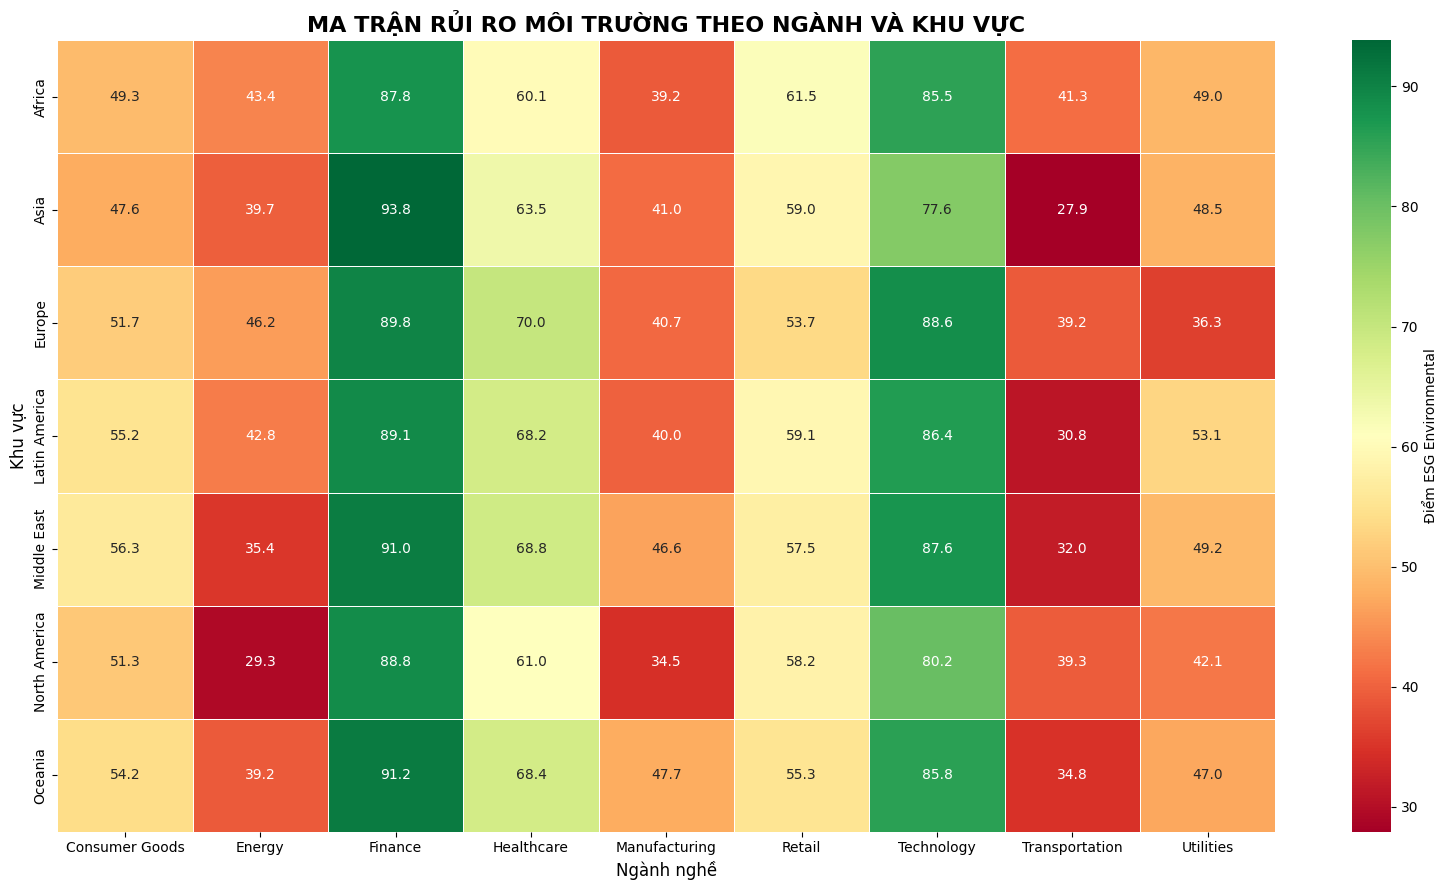

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

esg_env_matrix = df.groupby(['Region', 'Industry'])['ESG_Environmental'].mean().unstack()

plt.figure(figsize=(16, 9))
sns.heatmap(esg_env_matrix,
            annot=True,
            cmap='RdYlGn',
            fmt=".1f",
            linewidths=.5,
            cbar_kws={'label': 'Điểm ESG Environmental'})

plt.title('MA TRẬN RỦI RO MÔI TRƯỜNG THEO NGÀNH VÀ KHU VỰC', fontsize=16, fontweight='bold')
plt.xlabel('Ngành nghề', fontsize=12)
plt.ylabel('Khu vực', fontsize=12)


plt.tight_layout()
plt.show()

In [67]:
import plotly.express as px
import pandas as pd

df['GrowthRate'].fillna(df['GrowthRate'].median(), inplace=True)

treemap_data = df.groupby(['Region', 'Industry']).agg({
    'Revenue': 'sum',
    'ESG_Environmental': 'mean'
}).reset_index()

fig = px.treemap(
    treemap_data,
    path=[px.Constant("Toàn cầu"), 'Region', 'Industry'],
    values='Revenue',
    color='ESG_Environmental',
    color_continuous_scale='RdYlGn',
    title='TREEMAP PHÂN CẤP (GLOBAL → REGION → INDUSTRY)',
    height=700,
    width=1000
)

fig.update_traces(
    hovertemplate='<b>%{label}</b><br>Doanh thu: %{value:,.0f}M<br>Điểm E: %{color:.1f}'
)

fig.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    font_family='sans-serif'
)

fig.show()

/tmp/ipykernel_2058/1407886581.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [71]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors

metrics = ['ESG_Environmental', 'ESG_Social', 'ESG_Governance']
df_grouped = df.groupby('Industry')[metrics].mean().reset_index()

print("BẢNG SỐ LIỆU ESG TRUNG BÌNH THEO NGÀNH (DỮ LIỆU VẼ RADAR CHART):")
display(df_grouped.round(2))
print("-" * 80)


categories = ['ESG_Environmental', 'ESG_Social', 'ESG_Governance']
categories_closed = categories + [categories[0]]

industries = df_grouped['Industry'].unique()
num_industries = len(industries)
rows = 3
cols = 3

colors = plotly.colors.qualitative.Dark24
if len(colors) < num_industries:
    colors = (colors * ((num_industries // len(colors)) + 1))[:num_industries]


fig = make_subplots(
    rows=rows, cols=cols,
    specs=[[{'type': 'polar'}] * cols] * rows,
    subplot_titles=[f'<b>{industry}</b>' for industry in industries],
    vertical_spacing=0.1,
    horizontal_spacing=0.05
)


for i, (index, row_data) in enumerate(df_grouped.iterrows()):
    industry_name = row_data['Industry']
    values = [row_data['ESG_Environmental'], row_data['ESG_Social'], row_data['ESG_Governance']]
    values.append(values[0])

    current_row = (i // cols) + 1
    current_col = (i % cols) + 1

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories_closed,
        fill='toself',
        fillcolor=colors[i],
        opacity=0.6,
        line_color='black',
        name=industry_name,
        showlegend=False,
        hoverinfo='text',
        hovertext=[f'{cat}: {val:.2f}' for cat, val in zip(categories, values[:-1])]
    ), row=current_row, col=current_col)

    fig.update_polars(
        radialaxis=dict(
            visible=True,
            range=[0, 100],
            tickfont=dict(size=8, color='gray'),
            gridcolor='lightgray',
            linecolor='lightgray'
        ),
        angularaxis=dict(
            visible=True,
            tickfont=dict(size=9),
            rotation=90
        ),
        row=current_row, col=current_col
    )


fig.update_layout(
    title=dict(
        text="<b>Biểu đồ Radar: Phân bổ Điểm ESG Trung bình theo Ngành (Dashboard)</b>",
        x=0.5,
        font=dict(size=20)
    ),
    height=1000,
    width=1200,
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=50, r=50, t=120, b=50)
)

fig.show()

BẢNG SỐ LIỆU ESG TRUNG BÌNH THEO NGÀNH (DỮ LIỆU VẼ RADAR CHART):


,Industry,ESG_Environmental,ESG_Social,ESG_Governance
0,Consumer Goods,52.08,58.29,54.12
1,Energy,39.66,55.78,51.60
2,Finance,90.25,56.07,47.54
3,Healthcare,66.23,51.64,53.90
4,Manufacturing,41.50,57.28,52.61
5,Retail,57.70,55.81,53.53
6,Technology,84.29,57.46,48.29
7,Transportation,33.85,52.49,51.77
8,Utilities,46.18,56.75,51.87


--------------------------------------------------------------------------------


In [77]:
import plotly.express as px
import pandas as pd

avg_esg_environmental_by_industry = df.groupby('Industry')['ESG_Environmental'].mean().reset_index()
avg_esg_environmental_by_industry.rename(columns={'ESG_Environmental': 'Avg_ESG_Environmental'}, inplace=True)

df_2015_2025 = df[df['Year'].isin([2015, 2025])]
carbon_emissions_pivot = df_2015_2025.pivot_table(index='Industry', columns='Year', values='CarbonEmissions').reset_index()
carbon_emissions_pivot['CarbonEmissions_Growth_Pct'] = ((carbon_emissions_pivot[2025] - carbon_emissions_pivot[2015]) / carbon_emissions_pivot[2015]) * 100
carbon_growth_by_industry = carbon_emissions_pivot[['Industry', 'CarbonEmissions_Growth_Pct']]

scatter_data = pd.merge(avg_esg_environmental_by_industry,
                        carbon_growth_by_industry[['Industry', 'CarbonEmissions_Growth_Pct']],
                        on='Industry')

industry_investment_summary = df.groupby('Industry')[['MarketCap', 'Revenue']].mean().reset_index().sort_values(by='MarketCap', ascending=False)

revenue_to_merge = industry_investment_summary[['Industry', 'Revenue']].rename(columns={'Revenue': 'Revenue_y'})
scatter_data = pd.merge(scatter_data, revenue_to_merge, on='Industry', how='left')

highlight_industries = {
    'Technology': 'red',
    'Utilities': 'green',
    'Healthcare': 'orange'
}

scatter_data['Highlight_Category'] = scatter_data['Industry'].apply(
    lambda x: x if x in highlight_industries else 'Ngành khác'
)

color_map = {
    'Technology': highlight_industries['Technology'],
    'Utilities': highlight_industries['Utilities'],
    'Healthcare': highlight_industries['Healthcare'],
    'Ngành khác': 'grey'
}

category_order = list(highlight_industries.keys()) + ['Ngành khác']

COLOR_TEXT = '#401D15'

fig = px.scatter(
    scatter_data,
    x='Avg_ESG_Environmental',
    y='CarbonEmissions_Growth_Pct',
    color='Highlight_Category',
    color_discrete_map=color_map,
    category_orders={'Highlight_Category': category_order},
    size='Revenue_y',
    size_max=50,
    hover_name='Industry',
    hover_data={
        'Avg_ESG_Environmental': ':.2f',
        'CarbonEmissions_Growth_Pct': ':.2f%',
        'Revenue_y': ':,.0f',
        'Highlight_Category': False
    },
    title='<b>ESG_Environmental vs Tốc độ tăng Carbon theo ngành (Toàn cầu, 2015-2025)</b>',
    labels={
        'Avg_ESG_Environmental': 'Điểm ESG_Environmental trung bình toàn cầu',
        'CarbonEmissions_Growth_Pct': 'Tốc độ tăng Carbon Emissions (%) (2015-2025)',
        'Highlight_Category': 'Nhóm ngành',
        'Revenue_y': 'Doanh thu trung bình'
    },
    height=650,
    width=1000
)

fig.update_traces(
    marker=dict(line=dict(width=1, color='DarkSlateGrey')),
    selector=dict(mode='markers')
)

for index, row in scatter_data.iterrows():
    is_highlighted = row['Industry'] in highlight_industries
    font_size = 10 if is_highlighted else 8
    font_weight = 'bold' if is_highlighted else 'normal'

    fig.add_annotation(
        x=row['Avg_ESG_Environmental'],
        y=row['CarbonEmissions_Growth_Pct'],
        text=row['Industry'],
        showarrow=False,
        xanchor='left',
        yanchor='middle',
        xshift=25,
        font=dict(
            size=font_size,
            color='#000000',
            weight=font_weight
        )
    )


fig.update_layout(
    title_x=0.5,
    font_family='sans-serif',
    font_color=COLOR_TEXT,
    hoverlabel=dict(
        bgcolor='white',
        font_size=12,
        font_family='sans-serif'
    ),
    legend_title_text='Nhóm ngành',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    ),
    xaxis_title_font=dict(size=12, color=COLOR_TEXT),
    yaxis_title_font=dict(size=12, color=COLOR_TEXT)
)

fig.show()

/tmp/ipykernel_2058/252232830.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





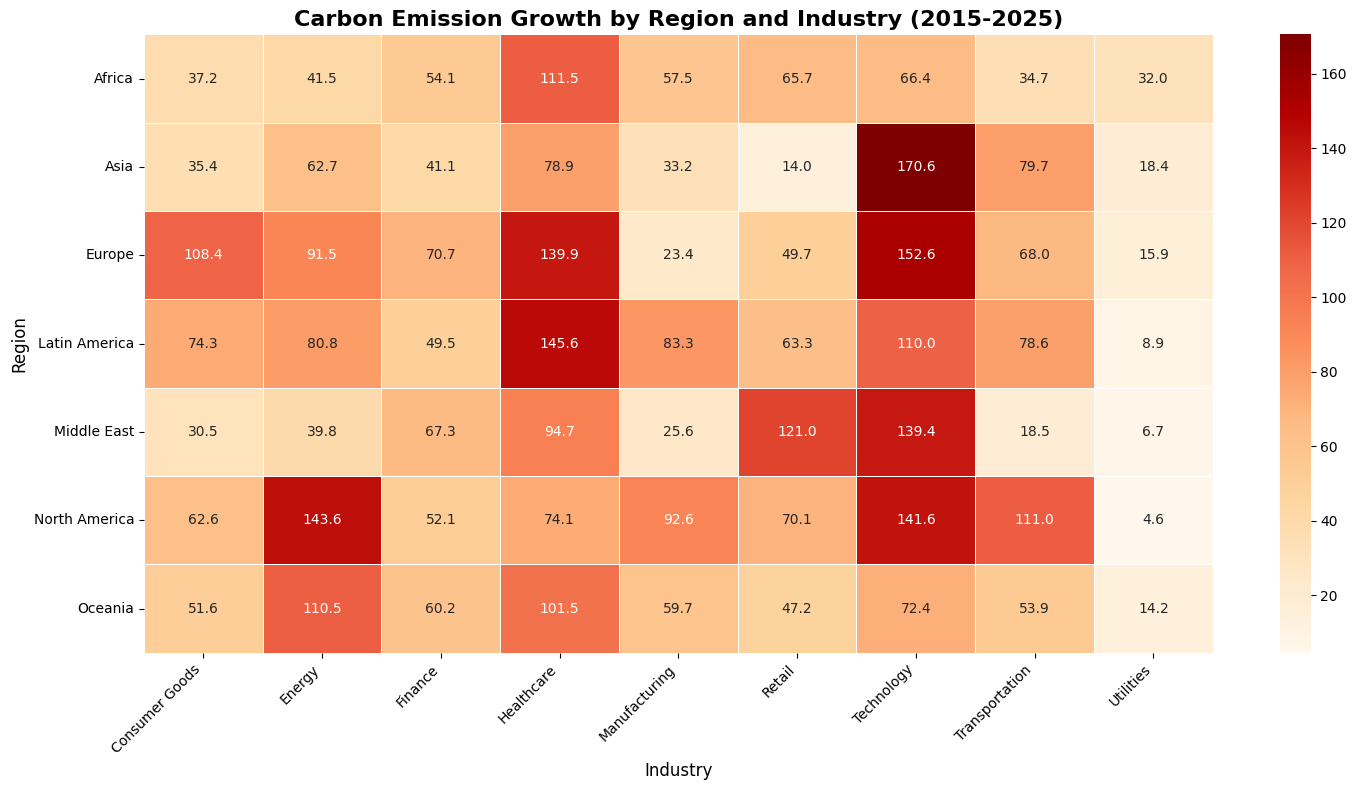

In [79]:
df['GrowthRate'].fillna(df['GrowthRate'].median(), inplace=True)

df_filtered_years = df[df['Year'].isin([2015, 2025])]

df_2015_region_industry = df_filtered_years[df_filtered_years['Year'] == 2015].groupby(['Region', 'Industry'])['CarbonEmissions'].mean().reset_index()
df_2025_region_industry = df_filtered_years[df_filtered_years['Year'] == 2025].groupby(['Region', 'Industry'])['CarbonEmissions'].mean().reset_index()

carbon_growth_by_region_industry = pd.merge(df_2015_region_industry,
                                            df_2025_region_industry,
                                            on=['Region', 'Industry'],
                                            suffixes=('_2015', '_2025'))

carbon_growth_by_region_industry['CarbonEmissions_Growth_Pct'] = ((carbon_growth_by_region_industry['CarbonEmissions_2025'] - carbon_growth_by_region_industry['CarbonEmissions_2015']) / carbon_growth_by_region_industry['CarbonEmissions_2015']) * 100

heatmap_data = carbon_growth_by_region_industry.pivot(
    index='Region',
    columns='Industry',
    values='CarbonEmissions_Growth_Pct'
)


plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, annot=True, cmap='OrRd', fmt=".1f", linewidths=.5)
plt.title('Carbon Emission Growth by Region and Industry (2015-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Industry', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('carbon_emission_growth_heatmap.png')
plt.show()

In [76]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

esg_regional_value = pd.DataFrame({
    'Region': ['Châu Âu', 'Latin America', 'Bắc Mỹ', 'Trung Đông', 'Châu Phi', 'Oceania', 'Châu Á'],
    'Added_MarketCap_per_ESG_point': [796.5, 778.9, 507.4, 466.0, 366.8, 269.0, 133.0],
    'ESG_Profit_Correlation': [0.231, 0.112, 0.169, 0.115, 0.126, 0.201, -0.127]
})

esg_regional_value_sorted = esg_regional_value.sort_values(by='Added_MarketCap_per_ESG_point', ascending=True)

fig1 = go.Figure()
fig1.add_trace(go.Bar(
    y=esg_regional_value_sorted['Region'],
    x=esg_regional_value_sorted['Added_MarketCap_per_ESG_point'],
    orientation='h',
    marker_color='rgb(102,194,164)',
    hovertemplate='<b>%{y}</b><br>Vốn hóa tăng thêm: %{x:,.1f} triệu USD'
))

fig1.update_layout(
    title_text='<b>Vốn hóa tăng thêm / 1 điểm ESG theo Khu vực</b>',
    title_x=0.5,
    yaxis_title='Khu vực',
    xaxis_title='Vốn hóa tăng thêm (triệu USD / 1 điểm ESG)',
    font=dict(family='sans-serif', size=12, color='black'),
    hovermode='y unified'
)
fig1.show()

colors = ['rgb(255,127,0)' if region == 'Châu Á' else 'rgb(66,133,244)' for region in esg_regional_value_sorted['Region']]

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    y=esg_regional_value_sorted['Region'],
    x=esg_regional_value_sorted['ESG_Profit_Correlation'],
    orientation='h',
    marker_color=colors,
    hovertemplate='<b>%{y}</b><br>Tương quan ESG-Lợi nhuận (r): %{x:.3f}'
))

fig2.update_layout(
    title_text='<b>Tương quan ESG - Lợi nhuận (r) theo Khu vực</b>',
    title_x=0.5,
    yaxis_title='Khu vực',
    xaxis_title='Hệ số tương quan (r)',
    font=dict(family='sans-serif', size=12, color='black'),
    hovermode='y unified'
)

fig2.add_shape(type='line', xref='x', yref='paper', x0=0, y0=0, x1=0, y1=1, line=dict(color='grey', width=1, dash='dot'))

fig2.show()